# 🧩 Unsupervised Learning — Complete Revision Notebook
### Module 4 | Day 2

Unsupervised Learning is the branch of Machine Learning where the model learns from **unlabeled data**
— there is no "correct answer" provided. Instead, the model discovers hidden structure, patterns, or
groupings in the data on its own.

This notebook covers:

1. What is Unsupervised Learning?
2. Supervised vs Unsupervised — Quick Comparison
3. Clustering — K-Means
4. Choosing K — the Elbow Method & Silhouette Score
5. Clustering — Hierarchical Clustering
6. Clustering — DBSCAN (density-based, handles noise/outliers)
7. Dimensionality Reduction — PCA
8. Putting It Together — PCA + Clustering
9. Real-World Applications
10. Key Takeaways


## 🐍 0. Setup — Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
np.random.seed(42)

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 1. What is Unsupervised Learning?

In Unsupervised Learning, we only have **input features (X)** — there is no target label (y). The
model's goal is to find structure in the data itself:

- Which data points are similar and should be **grouped together**? (Clustering)
- Can we **reduce the number of features** while keeping the important information? (Dimensionality Reduction)
- Which data points look **unusual or different** from the rest? (Anomaly Detection)

### 2. Supervised vs Unsupervised — Quick Comparison

| | Supervised Learning | Unsupervised Learning |
|---|---|---|
| **Data** | Labeled (X, y) | Unlabeled (X only) |
| **Goal** | Predict a known label | Discover hidden structure |
| **Example task** | Predict pass/fail | Group similar customers |
| **Example algorithms** | Linear/Logistic Regression, Random Forest | K-Means, PCA, DBSCAN |
| **Evaluation** | Accuracy, F1, RMSE (compare to ground truth) | Silhouette Score, inertia (no ground truth) |


---
## 3. Clustering — K-Means

**K-Means** groups data into **K clusters** by:

1. Randomly placing K cluster centers ("centroids")
2. Assigning every point to its nearest centroid
3. Moving each centroid to the average position of its assigned points
4. Repeating steps 2–3 until the centroids stop moving

We'll simulate **customer data** (annual spending vs visit frequency) and let K-Means discover
natural customer segments — with no labels given.


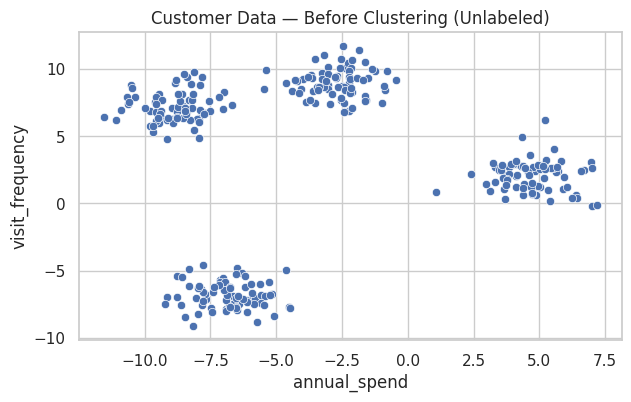

In [2]:
# Create synthetic customer data with 4 natural groups
X_blobs, true_labels = make_blobs(
    n_samples=300, centers=4, cluster_std=1.1, random_state=42
)

customer_df = pd.DataFrame(X_blobs, columns=["annual_spend", "visit_frequency"])

plt.figure()
sns.scatterplot(data=customer_df, x="annual_spend", y="visit_frequency", color="#4C72B0")
plt.title("Customer Data — Before Clustering (Unlabeled)")
plt.show()


In [3]:
# Scale features (important for distance-based algorithms like K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df)

# Fit K-Means with K = 4
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
customer_df["cluster"] = kmeans.fit_predict(X_scaled)

customer_df.head()


   annual_spend  visit_frequency  cluster
0     -9.343625         6.388694        3
1     -9.784782         6.900512        3
2     -1.604398         7.671358        0
3     -7.119077        -5.671455        1
4    -11.080265         6.214628        3

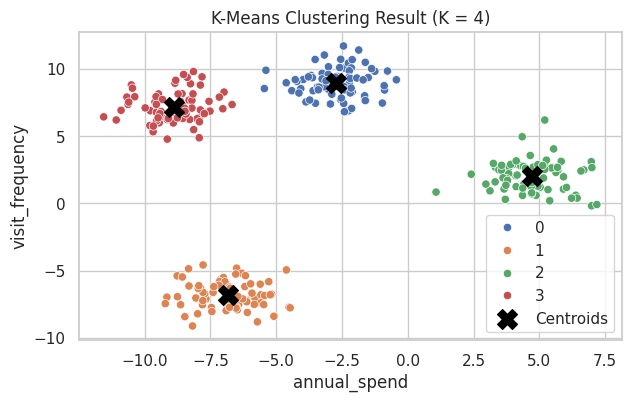

In [4]:
# Visualize the discovered clusters + centroids
plt.figure()
sns.scatterplot(
    data=customer_df, x="annual_spend", y="visit_frequency",
    hue="cluster", palette="deep", legend="full"
)

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_original[:, 0], centroids_original[:, 1],
    marker="X", s=200, c="black", label="Centroids"
)
plt.title("K-Means Clustering Result (K = 4)")
plt.legend()
plt.show()


## 4. Choosing K — The Elbow Method & Silhouette Score

In real problems we don't know the "true" number of clusters in advance. Two common ways to choose K:

- **Elbow Method** — plot inertia (within-cluster sum of squares) for different K values; the "elbow"
  point where the curve bends is a good candidate for K.
- **Silhouette Score** — measures how similar a point is to its own cluster vs other clusters
  (ranges from -1 to 1; higher is better).


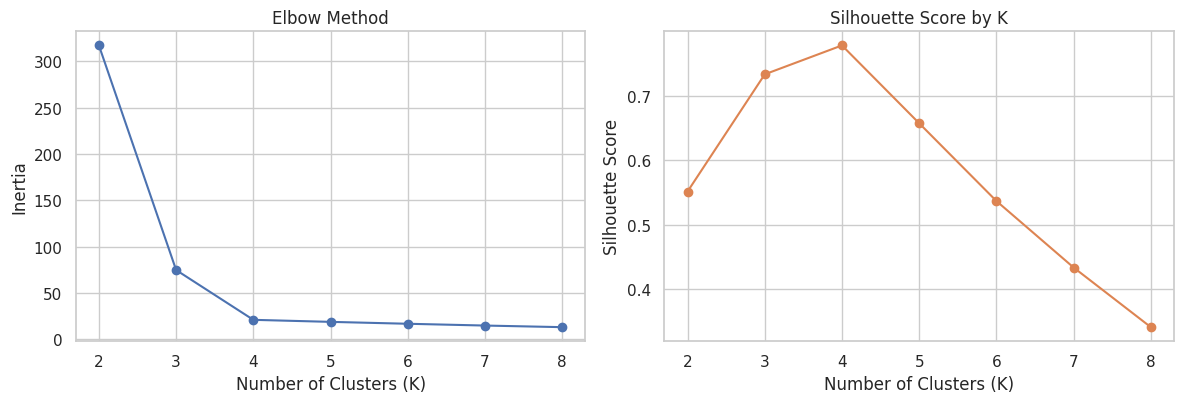

In [5]:
inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(list(k_range), inertias, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


Both plots point to **K = 4** as the best choice here — matching the true underlying structure we
generated (which K-Means had no access to).


---
## 5. Clustering — Hierarchical Clustering

**Hierarchical Clustering** builds a tree of clusters (a **dendrogram**) by iteratively merging the
closest pairs of points/clusters. Unlike K-Means, you don't need to choose K upfront — you can "cut"
the dendrogram at any height to get a chosen number of clusters.


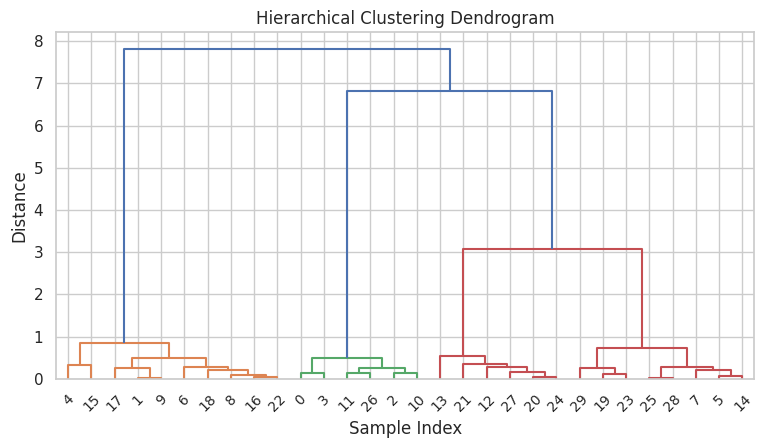

In [6]:
# Use a small sample for a readable dendrogram
sample = customer_df.sample(30, random_state=42)[["annual_spend", "visit_frequency"]]
sample_scaled = StandardScaler().fit_transform(sample)

linked = linkage(sample_scaled, method="ward")

plt.figure(figsize=(9, 4.5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()


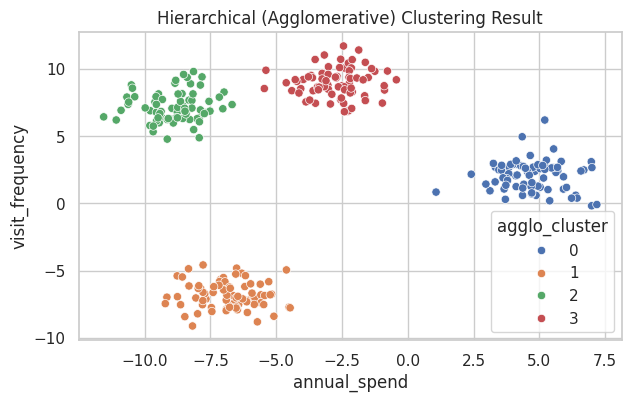

In [7]:
# Agglomerative Clustering with 4 clusters (cutting the dendrogram)
agglo = AgglomerativeClustering(n_clusters=4)
customer_df["agglo_cluster"] = agglo.fit_predict(X_scaled)

plt.figure()
sns.scatterplot(
    data=customer_df, x="annual_spend", y="visit_frequency",
    hue="agglo_cluster", palette="deep"
)
plt.title("Hierarchical (Agglomerative) Clustering Result")
plt.show()


## 6. Clustering — DBSCAN (Density-Based)

**DBSCAN** groups points that are closely packed together (dense regions) and marks points in
low-density regions as **noise/outliers** — unlike K-Means, it doesn't force every point into a
cluster, and it doesn't require choosing K in advance.

Key parameters:
- **eps** — the maximum distance between two points to be considered neighbors
- **min_samples** — minimum number of points required to form a dense region


Clusters found: 3
Noise points (label = -1): 0


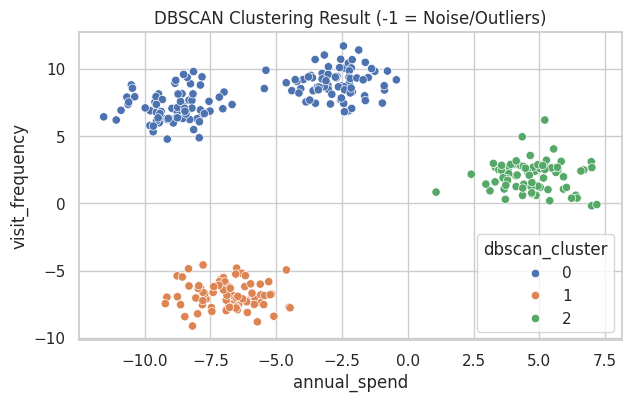

In [8]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
customer_df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(customer_df["dbscan_cluster"])) - (1 if -1 in customer_df["dbscan_cluster"].values else 0)
n_noise = (customer_df["dbscan_cluster"] == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points (label = -1): {n_noise}")

plt.figure()
sns.scatterplot(
    data=customer_df, x="annual_spend", y="visit_frequency",
    hue="dbscan_cluster", palette="deep", legend="full"
)
plt.title("DBSCAN Clustering Result (-1 = Noise/Outliers)")
plt.show()


---
## 7. Dimensionality Reduction — PCA

Real datasets often have **many features** (sometimes hundreds), which makes them hard to visualize
and can slow down or confuse ML models (the "curse of dimensionality"). **Principal Component
Analysis (PCA)** reduces the number of features while preserving as much of the original variance
(information) as possible.

We'll use the classic **Iris dataset** (4 features) and reduce it down to 2 principal components so
we can visualize it in a simple 2D scatter plot.


In [9]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["species"] = iris.target

print("Original shape:", iris_df.drop(columns=['species']).shape)
iris_df.head()


Original shape: (150, 4)


   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2        0
1                4.9               3.0  ...               0.2        0
2                4.7               3.2  ...               0.2        0
3                4.6               3.1  ...               0.2        0
4                5.0               3.6  ...               0.2        0

[5 rows x 5 columns]

In [10]:
# Standardize features before PCA (PCA is sensitive to feature scale)
iris_scaled = StandardScaler().fit_transform(iris_df.drop(columns=["species"]))

pca = PCA(n_components=2)
iris_pca = pca.fit_transform(iris_scaled)

print("Reduced shape:", iris_pca.shape)
print("Variance explained by each component:", np.round(pca.explained_variance_ratio_, 3))
print("Total variance retained:", round(pca.explained_variance_ratio_.sum() * 100, 1), "%")


Reduced shape: (150, 2)
Variance explained by each component: [0.73  0.229]
Total variance retained: 95.8 %


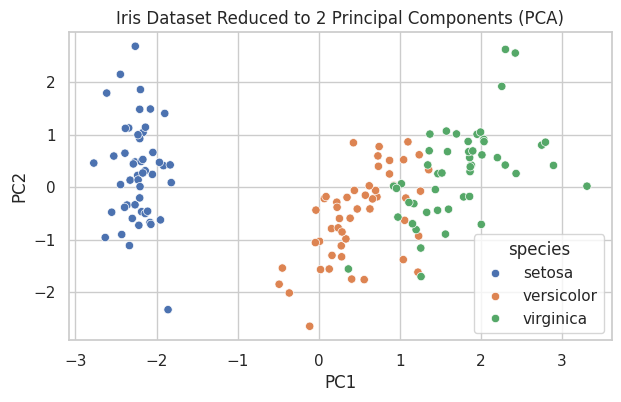

In [11]:
pca_df = pd.DataFrame(iris_pca, columns=["PC1", "PC2"])
pca_df["species"] = iris_df["species"].map(dict(enumerate(iris.target_names)))

plt.figure()
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", palette="deep")
plt.title("Iris Dataset Reduced to 2 Principal Components (PCA)")
plt.show()


Even though PCA had **no access to the species labels**, the 2D projection naturally separates the
three species — showing how much structure PCA can preserve while dropping half the original
features.


## 8. Putting It Together — PCA + K-Means

A common real-world pattern: use PCA to reduce dimensionality first, then cluster the reduced data.
This can make clustering faster and sometimes more accurate on high-dimensional data.


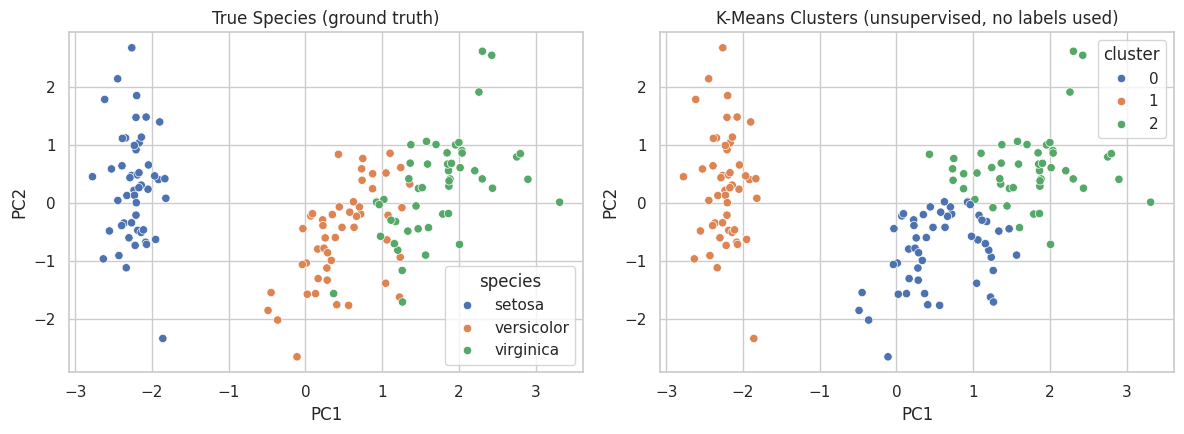

In [12]:
kmeans_pca = KMeans(n_clusters=3, n_init=10, random_state=42)
pca_df["cluster"] = kmeans_pca.fit_predict(iris_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", palette="deep", ax=axes[0])
axes[0].set_title("True Species (ground truth)")

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="deep", ax=axes[1])
axes[1].set_title("K-Means Clusters (unsupervised, no labels used)")

plt.tight_layout()
plt.show()


Notice how closely the unsupervised clusters (right) match the true species groups (left) — even
though K-Means never saw the species labels. This is the essence of unsupervised learning: finding
meaningful structure purely from the data itself.


## 9. Real-World Applications of Unsupervised Learning

| Technique | Real-World Use Case |
|---|---|
| **K-Means / Hierarchical Clustering** | Customer segmentation, market research |
| **DBSCAN** | Anomaly/fraud detection, geographic hotspot detection |
| **PCA** | Data compression, noise reduction, visualization of high-dimensional data |
| **Clustering + PCA** | Gene expression analysis, image compression, recommender systems |
| **Anomaly Detection** | Fraud detection, network intrusion detection, manufacturing defect detection |


---
## 🔑 Key Takeaways

- **Unsupervised Learning** finds structure in data **without labels** — the model isn't told the "right answer."
- **K-Means** partitions data into K clusters by iteratively updating centroids; K must be chosen in advance.
- The **Elbow Method** and **Silhouette Score** help choose a good value of K.
- **Hierarchical Clustering** builds a dendrogram and doesn't require choosing K upfront.
- **DBSCAN** finds clusters based on density and can automatically detect outliers/noise.
- **PCA** reduces the number of features while preserving as much variance (information) as possible — useful for visualization and speeding up downstream models.
- Combining **PCA + Clustering** is a common real-world pattern for high-dimensional data.
- Unlike supervised learning, there's no ground-truth accuracy — evaluation relies on internal metrics like silhouette score and domain judgment.

**Module 4 complete:** Supervised Learning (Day 1) + Unsupervised Learning (Day 2) — the two core paradigms of Machine Learning.
